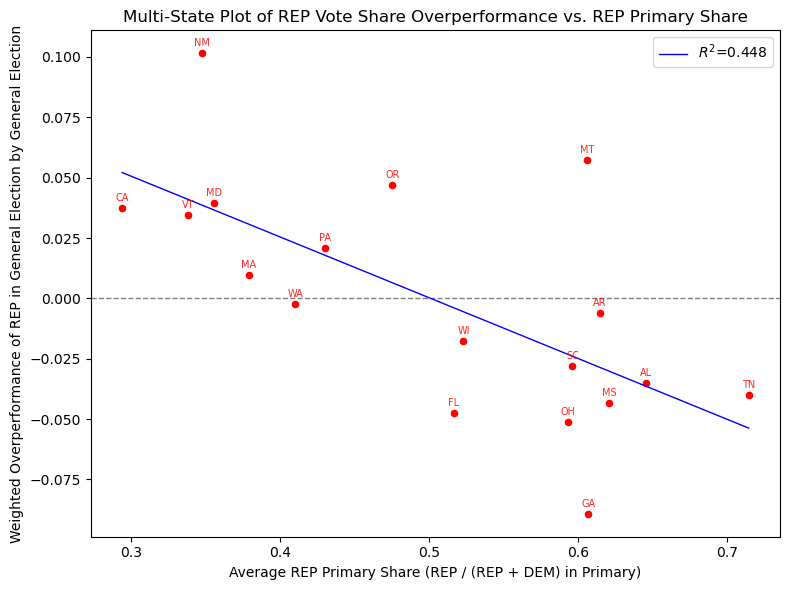

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob
from scipy.stats import linregress

# Path to the data folder containing all state CSVs
data_folder = '../data/Final Data'

# Find all CSV files in the folder
csv_files = glob(os.path.join(data_folder, '*.csv'))

# Mapping from full state names or filenames to 2-letter abbreviations
state_abbrev = {
    'Oregon': 'OR', 'Washington': 'WA', 'California': 'CA', 'Idaho': 'ID', 'Nevada': 'NV',
    'Montana': 'MT', 'Wyoming': 'WY', 'Utah': 'UT', 'Colorado': 'CO', 'Arizona': 'AZ',
    'NewMexico': 'NM', 'Texas': 'TX', 'Oklahoma': 'OK', 'Kansas': 'KS', 'Nebraska': 'NE',
    'SouthDakota': 'SD', 'NorthDakota': 'ND', 'Minnesota': 'MN', 'Iowa': 'IA', 'Missouri': 'MO',
    'Arkansas': 'AR', 'Louisiana': 'LA', 'Mississippi': 'MS', 'Alabama': 'AL', 'Georgia': 'GA',
    'Florida': 'FL', 'SouthCarolina': 'SC', 'NorthCarolina': 'NC', 'Tennessee': 'TN', 'Kentucky': 'KY',
    'WestVirginia': 'WV', 'Virginia': 'VA', 'Maryland': 'MD', 'Delaware': 'DE', 'Pennsylvania': 'PA',
    'NewJersey': 'NJ', 'NewYork': 'NY', 'Connecticut': 'CT', 'RhodeIsland': 'RI', 'Massachusetts': 'MA',
    'Vermont': 'VT', 'NewHampshire': 'NH', 'Maine': 'ME', 'Illinois': 'IL', 'Indiana': 'IN',
    'Ohio': 'OH', 'Michigan': 'MI', 'Wisconsin': 'WI', 'Alaska': 'AK', 'Hawaii': 'HI'
}

state_points = []

for file_path in csv_files:
    try:
        # Use the filename (without extension) as the state name
        file_name = os.path.basename(file_path)
        state = os.path.splitext(file_name)[0]

        # Try to get 2-letter abbreviation, fallback to first 2 letters
        abbrev = state_abbrev.get(state, state[:2].upper())

        df = pd.read_csv(file_path)
        # Calculate primary and general REP vote share per precinct

        # Calculate total primary votes by summing all columns that start with 'pri_'
        if 'pri_total' in df.columns:
            df['pri_total'] = df['pri_total']
        else:
            pri_cols = [col for col in df.columns if col.startswith('pri_')]
            df['pri_total'] = df[pri_cols].sum(axis=1)
            
        # Check if gen_total column exists, otherwise calculate from gen_ columns
        if 'gen_total' in df.columns:
            df['gen_total'] = df['gen_total']
        else:
            gen_cols = [col for col in df.columns if col.startswith('gen_')]
            df['gen_total'] = df[gen_cols].sum(axis=1)

        # Avoid division by zero
        df = df[df['pri_total'] > 0]
        df = df[df['gen_total'] > 0]

        # Calculate all columns that start with 'pri_rep' and sum them as 'pri_rep_total'
        pri_rep_cols = [col for col in df.columns if col.startswith('pri_rep')]
        df['pri_rep_total'] = df[pri_rep_cols].sum(axis=1)
        # Calculate all columns that start with 'pri_dem' and sum them as 'pri_dem_total'
        pri_dem_cols = [col for col in df.columns if col.startswith('pri_dem')]
        df['pri_dem_total'] = df[pri_dem_cols].sum(axis=1)

        # Calculate all columns that start with 'gen_rep' and sum them as 'gen_rep_total'
        gen_rep_cols = [col for col in df.columns if col.startswith('gen_rep')]
        df['gen_rep_total'] = df[gen_rep_cols].sum(axis=1)
        # Calculate all columns that start with 'gen_dem' and sum them as 'gen_dem_total'
        gen_dem_cols = [col for col in df.columns if col.startswith('gen_dem')]
        df['gen_dem_total'] = df[gen_dem_cols].sum(axis=1)

        # Calculate REP primary share as rep pri / (dem pri + rep pri)
        # Avoid division by zero
        df['rep_primary_share'] = np.where(
            (df['pri_rep_total'] + df['pri_dem_total']) > 0,
            df['pri_rep_total'] / (df['pri_rep_total']+df['pri_dem_total']),
            np.nan
        )
        df = df[df['rep_primary_share'].notnull()]

        df['rep_general_share'] = df['gen_rep_total'] / (df['gen_rep_total']+df['gen_dem_total'])
        df['diff'] = df['rep_general_share'] - df['rep_primary_share']

        # Calculate weights: precinct primary votes / total state primary votes
        gen_total_state = df['gen_total'].sum()
        df['weight'] = df['gen_total'] / gen_total_state

        # Weighted residual for the state (y-axis)
        weighted_residual = (df['diff'] * df['gen_total']).sum() / gen_total_state

        # Average REP primary share for the state (x-axis) -- using new definition
        avg_rep_primary_share = df['rep_primary_share'].mean()

        state_points.append({
            'state': state,
            'abbrev': abbrev,
            'weighted_residual': weighted_residual,
            'avg_rep_primary_share': avg_rep_primary_share
        })
    except Exception as e:
        print(f"Error processing {file_path}: {e}")

# Convert to DataFrame for plotting
state_df = pd.DataFrame(state_points)

# Fit regression line and calculate R^2
x = state_df['avg_rep_primary_share']
y = state_df['weighted_residual']
slope, intercept, r_value, p_value, std_err = linregress(x, y)
r_squared = r_value ** 2

# Plot
plt.figure(figsize=(8, 6))
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.scatter(x, y, color='red', s=20)

# Plot regression line
x_vals = np.linspace(x.min(), x.max(), 100)
y_vals = slope * x_vals + intercept
plt.plot(x_vals, y_vals, color='blue', linestyle='-', linewidth=1, label=f"$R^2$={r_squared:.3f}")

# Annotate each state with its 2-letter abbreviation only (no coordinates)
for i, row in state_df.iterrows():
    label = f"{row['abbrev']}"
    plt.annotate(
        label,
        (row['avg_rep_primary_share'], row['weighted_residual']),
        textcoords="offset points",
        xytext=(0, 5),
        ha='center',
        fontsize=7,
        color='red',
        fontweight='normal',  # less bold
        alpha=0.85
    )

plt.xlabel("Average REP Primary Share (REP / (REP + DEM) in Primary)")
plt.ylabel("Weighted Overperformance of REP in General Election by General Election")
plt.title("Multi-State Plot of REP Vote Share Overperformance vs. REP Primary Share")
plt.legend()
plt.tight_layout()
plt.show()


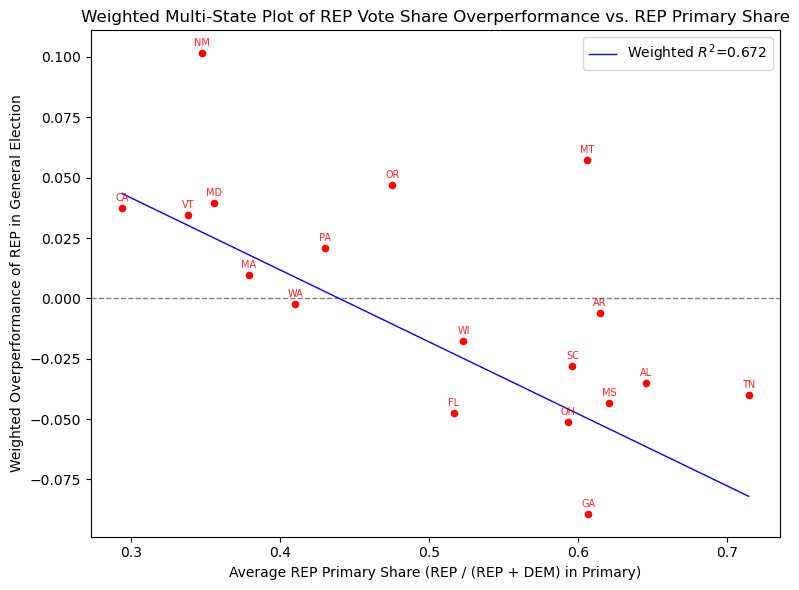

In [15]:
import statsmodels.api as sm

# Compute total general election votes for each state using the original CSV filenames
def get_total_gen_votes(row):
    # Try to find the original file by matching the state name (not abbrev)
    # Use the 'state' field from state_df, which matches the original filename
    file_path = os.path.join(data_folder, f"{row['state']}.csv")
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            # If 'gen_total' exists, use it; otherwise, sum gen_ columns
            if 'gen_total' in df.columns:
                return df['gen_total'].sum()
            else:
                gen_cols = [col for col in df.columns if col.startswith('gen_')]
                return df[gen_cols].sum().sum()
        except Exception as e:
            print(f"Error reading {file_path}: {e}")
            return np.nan
    else:
        return np.nan

state_df['total_gen_votes'] = state_df.apply(get_total_gen_votes, axis=1)

# Drop states with missing total_gen_votes
state_df = state_df.dropna(subset=['total_gen_votes'])

# Prepare variables for weighted regression
X = sm.add_constant(state_df['avg_rep_primary_share'])
y = state_df['weighted_residual']
weights = state_df['total_gen_votes']

# Fit weighted least squares regression
wls_model = sm.WLS(y, X, weights=weights).fit()
r_squared_weighted = wls_model.rsquared

# Regression line for plotting
x_vals = np.linspace(state_df['avg_rep_primary_share'].min(),
                     state_df['avg_rep_primary_share'].max(), 100)
y_vals = wls_model.predict(sm.add_constant(x_vals))

# Plot
plt.figure(figsize=(8, 6))
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.scatter(state_df['avg_rep_primary_share'], state_df['weighted_residual'],
            color='red', s=20)

plt.plot(x_vals, y_vals, color='blue', linestyle='-', linewidth=1,
         label=f"Weighted $R^2$={r_squared_weighted:.3f}")

# Annotate state labels
for i, row in state_df.iterrows():
    plt.annotate(row['abbrev'],
                 (row['avg_rep_primary_share'], row['weighted_residual']),
                 textcoords="offset points", xytext=(0, 5),
                 ha='center', fontsize=7, color='red', alpha=0.85)

plt.xlabel("Average REP Primary Share (REP / (REP + DEM) in Primary)")
plt.ylabel("Weighted Overperformance of REP in General Election")
plt.title("Weighted Multi-State Plot of REP Vote Share Overperformance vs. REP Primary Share")
plt.legend()
plt.tight_layout()
plt.show()
